# Paper figures: originals vs reproductions

1. **Next cell:** imports, paths, plotting helpers.
2. **After that:** set each figure’s run folder (name under `results/repro/`, or `""` for the latest match). Figure 5 uses a directory of `sushi_*.json` files.
3. **Below:** each section shows the paper figure, then the reproduction plot.

In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "configs").is_dir():
    for parent in Path.cwd().parents:
        if (parent / "configs").is_dir() and (parent / "scripts").is_dir():
            ROOT = parent
            break

RESULTS = ROOT / "results" / "repro"
FIG_ORIGINAL = ROOT / "docs" / "original paper" / "figures"


def _resolve_run_dir(name: str, glob_pat: str) -> Path:
    if name.strip():
        p = RESULTS / name.strip()
        if not p.is_dir():
            raise FileNotFoundError(f"Not a directory: {p}")
        return p
    cands = sorted(p for p in RESULTS.glob(glob_pat) if p.is_dir())
    if not cands:
        raise FileNotFoundError(f"No run folder under {RESULTS} matching {glob_pat!r}")
    return cands[-1]


def _resolve_sushi_dir(dir_name: str) -> Path:
    if dir_name.strip():
        p = Path(dir_name.strip())
        if not p.is_absolute():
            p = ROOT / p
        if not p.is_dir():
            raise FileNotFoundError(f"Not a directory: {p}")
        return p
    d = RESULTS / "sushi"
    if d.is_dir():
        return d
    raise FileNotFoundError(f"No sushi directory; set FIG5_SUSHI_DIR or create {d}")


def load_criteria_curve_df(run_dir: Path) -> pd.DataFrame:
    path = run_dir / "aggregates" / "criteria_curve.json"
    if not path.exists():
        return pd.DataFrame()
    payload = json.loads(path.read_text(encoding="utf-8"))
    series_by_crit: dict[str, dict[int, float]] = defaultdict(dict)
    for row in payload.get("summary", []):
        series_by_crit[row["criterion"]][int(row["n_observations"])] = float(row["mean"])
    df = pd.DataFrame(series_by_crit)
    return df.sort_index() if not df.empty else df

#TODO: delete later
def load_criteria_curve_df_old(run_dir: Path) -> pd.DataFrame:
    path = run_dir / "aggregates" / "criteria.json"
    if not path.exists():
        return pd.DataFrame()
    payload = json.loads(path.read_text(encoding="utf-8"))
    series_by_crit: dict[str, dict[int, float]] = defaultdict(dict)
    for row in payload.get("summary", []):
        series_by_crit[row["criterion"]][int(row["rounds"])] = float(row["mean"])
    df = pd.DataFrame(series_by_crit)
    return df.sort_index() if not df.empty else df

def smooth_curve(df: pd.DataFrame, window: int) -> pd.DataFrame:
    if df.empty:
        return df
    return df.rolling(window=window, min_periods=1).mean()


def show_original(fig_name: str) -> None:
    p = FIG_ORIGINAL / fig_name
    if not p.is_file():
        raise FileNotFoundError(f"Missing paper figure: {p}")
    display(Image(filename=str(p)))


STYLE_MAP = {
    "random": {"color": "blue", "linestyle": "--"},
    "social": {"color": "red", "linestyle": "-"},
    "d_opt": {"color": "orange", "linestyle": "-."},
    "e_opt": {"color": "green", "linestyle": ":"},
    "personalized": {"color": "purple", "linestyle": "-"},
}
LABEL_MAP = {
    "random": "Random",
    "social": "Social",
    "d_opt": "D-optimality",
    "e_opt": "E-optimality",
    "personalized": "Personalized",
}


def plot_kendall_panel(ax, df: pd.DataFrame, title: str) -> None:
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    for crit in df.columns:
        if crit in STYLE_MAP:
            ax.plot(df.index, df[crit], label=LABEL_MAP.get(crit, crit), **STYLE_MAP[crit])
        else:
            ax.plot(df.index, df[crit], label=crit)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Number of Agents", fontsize=12)
    ax.set_ylabel("Kendall Correlation", fontsize=12)
    ax.set_xlim(left=20, right=75)
    ax.grid(True, linestyle="--", alpha=0.5)


In [4]:
# Folder names under results/repro/, or "" to take the latest matching run.
FIG2_RUN = "fig2-repro-20260322-094422"
FIG3_DATASET1_RUN = "fig3-dataset1-repro-20260322-122744"
FIG3_DATASET2_RUN = "fig3-dataset2-repro-20260322-124826"
FIG4_DATASET1_RUN = "fig4-dataset1-repro-20260322-133323"
FIG4_DATASET2_RUN = "fig4-dataset2-repro-20260322-135825"
FIG6_RUN = "fig6-repro-20260322-134849"
# Directory containing sushi_random.json, … (absolute, or relative to repo root), or "" for results/repro/sushi
FIG5_SUSHI_DIR = "results/repro/sushi"


## Figure 2

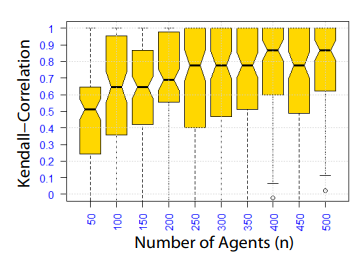

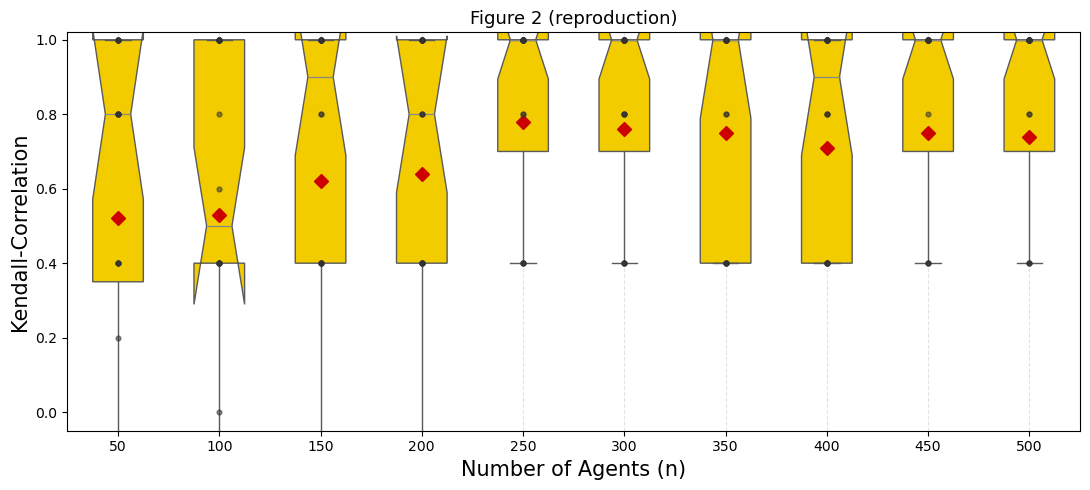

In [3]:
show_original("Figure2.png")

R = _resolve_run_dir(FIG2_RUN, "fig2-repro-*")
fig2_samples_by_count: dict[int, list[float]] = {}
agg_path = R / "aggregates" / "asymptotic.json"
if agg_path.exists():
    agg_payload = json.loads(agg_path.read_text(encoding="utf-8"))
    by_count: dict[int, list[float]] = defaultdict(list)
    for row in agg_payload.get("rows", []):
        by_count[int(row["n_agents"])].append(float(row["mean_tau"]))
    fig2_samples_by_count = {k: by_count[k] for k in sorted(by_count.keys())}
else:
    by_count = defaultdict(list)
    for fp in sorted((R / "outputs").glob("*.json")):
        payload = json.loads(fp.read_text(encoding="utf-8"))
        for point in payload.get("asymptotic", []):
            by_count[int(point["n_agents"])].append(float(point["mean_tau"]))
    fig2_samples_by_count = {k: by_count[k] for k in sorted(by_count.keys())}

counts = sorted(fig2_samples_by_count.keys())
if not counts:
    raise ValueError("No asymptotic points in selected Figure 2 run.")

plot_data = [fig2_samples_by_count[n] for n in counts]
plt.figure(figsize=(11, 5))
plt.boxplot(
    plot_data,
    tick_labels=[str(n) for n in counts],
    notch=True,
    patch_artist=True,
    showfliers=True,
    showmeans=True,
    whis=1.5,
    medianprops={"color": "#888888", "linewidth": 0.9},
    meanprops={"marker": "D", "markerfacecolor": "#cc0000", "markeredgecolor": "#cc0000", "markersize": 7},
    boxprops={"facecolor": "#f3cc00", "edgecolor": "#5a5a5a", "linewidth": 1.0},
    whiskerprops={"color": "#5a5a5a", "linewidth": 1.0},
    capprops={"color": "#5a5a5a", "linewidth": 1.0},
    flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#888888", "markeredgecolor": "#666666", "alpha": 0.8},
)
for i, n in enumerate(counts, start=1):
    vals = np.array(fig2_samples_by_count[n], dtype=float)
    plt.scatter(np.full(vals.shape, i, dtype=float), vals, s=12, color="#333333", alpha=0.55, zorder=3)
plt.xlabel("Number of Agents (n)", fontsize=15)
plt.ylabel("Kendall-Correlation", fontsize=15)
plt.ylim(-0.05, 1.02)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.title("Figure 2 (reproduction)", fontsize=13)
plt.tight_layout()
plt.show()


## Figure 3

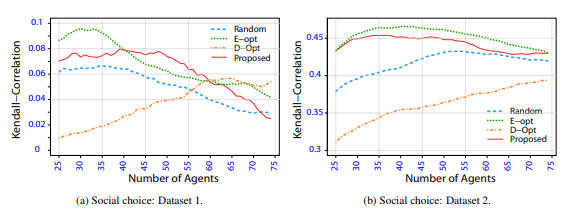

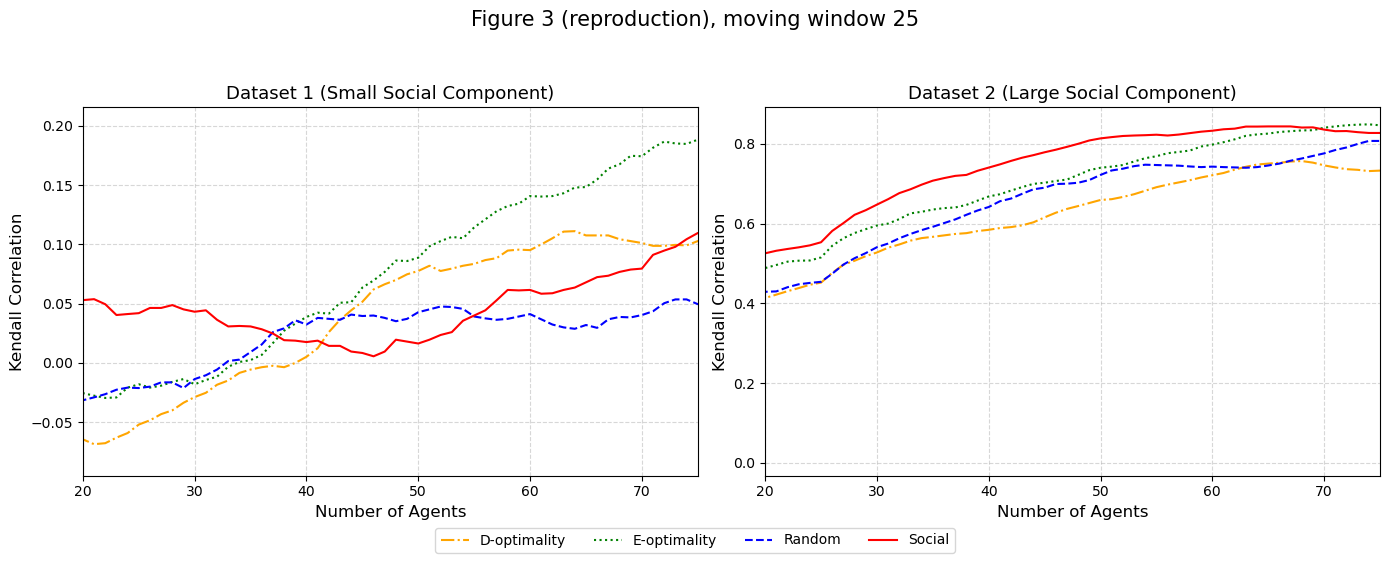

In [4]:
show_original("Figure3.png")

R1 = _resolve_run_dir(FIG3_DATASET1_RUN, "fig3-dataset1-repro-*")
R2 = _resolve_run_dir(FIG3_DATASET2_RUN, "fig3-dataset2-repro-*")
df3_1 = smooth_curve(load_criteria_curve_df(R1), 25)
df3_2 = smooth_curve(load_criteria_curve_df(R2), 25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_kendall_panel(ax1, df3_1, "Dataset 1 (Small Social Component)")
plot_kendall_panel(ax2, df3_2, "Dataset 2 (Large Social Component)")
if not df3_1.empty or not df3_2.empty:
    h, lab = ax1.get_legend_handles_labels()
    fig.legend(h, lab, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Figure 3 (reproduction), moving window 25", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


## Figure 4

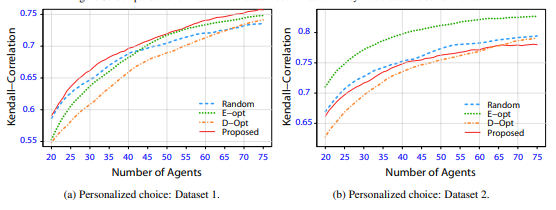

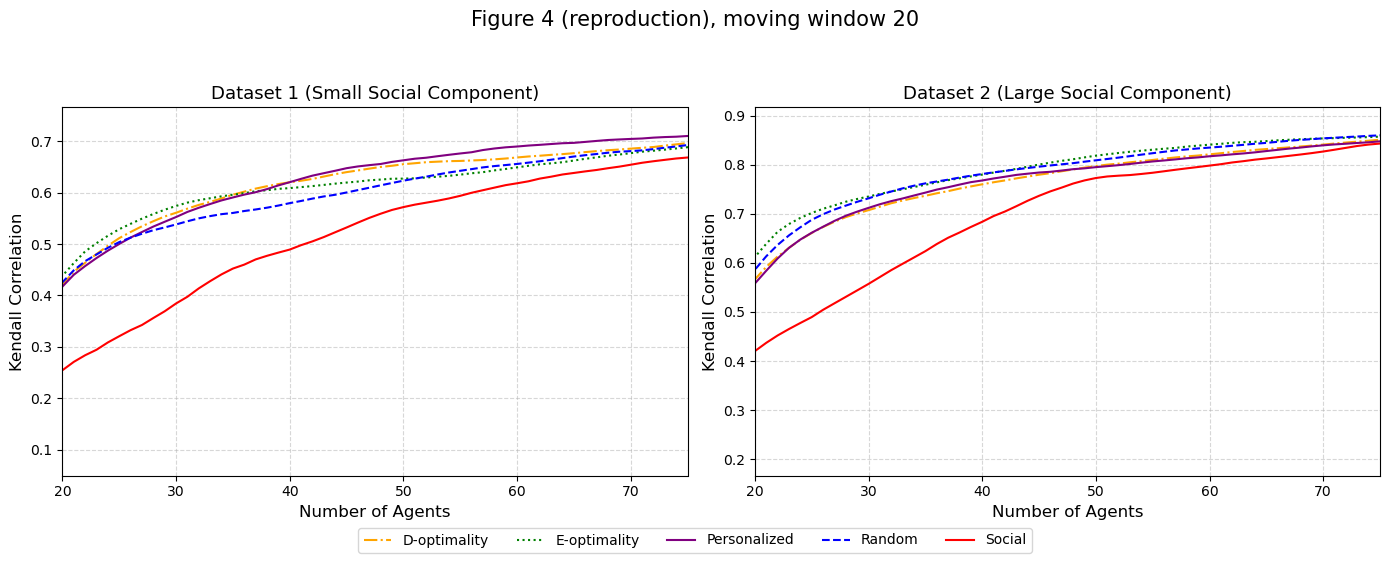

In [5]:
show_original("Figure4.png")

R1 = _resolve_run_dir(FIG4_DATASET1_RUN, "fig4-dataset1-repro-*")
R2 = _resolve_run_dir(FIG4_DATASET2_RUN, "fig4-dataset2-repro-*")
df4_1 = smooth_curve(load_criteria_curve_df(R1), 20)
df4_2 = smooth_curve(load_criteria_curve_df(R2), 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_kendall_panel(ax1, df4_1, "Dataset 1 (Small Social Component)")
plot_kendall_panel(ax2, df4_2, "Dataset 2 (Large Social Component)")
if not df4_1.empty or not df4_2.empty:
    h, lab = ax1.get_legend_handles_labels()
    fig.legend(h, lab, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Figure 4 (reproduction), moving window 20", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


## Figure 5

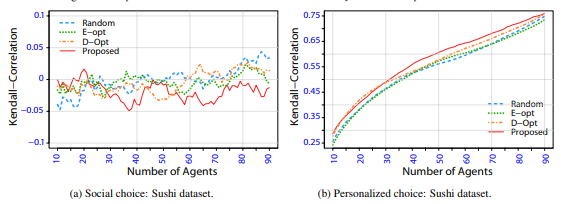

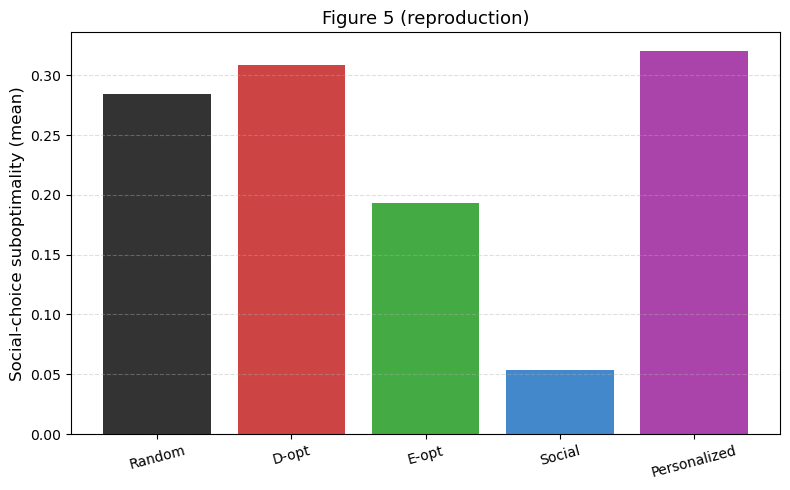

In [5]:
show_original("Figure5.png")

SUSHI_DIR = _resolve_sushi_dir(FIG5_SUSHI_DIR)
order = ["random", "d_opt", "e_opt", "social", "personalized"]
labels = ["Random", "D-opt", "E-opt", "Social", "Personalized"]
scores: list[float] = []
for key in order:
    fp = SUSHI_DIR / f"sushi_{key}.json"
    if not fp.is_file():
        scores.append(float("nan"))
        continue
    payload = json.loads(fp.read_text(encoding="utf-8"))
    block = payload.get("criteria") or {}
    if key not in block and len(block) == 1:
        scores.append(float(next(iter(block.values()))))
    else:
        scores.append(float(block[key]))

plt.figure(figsize=(8, 5))
x = np.arange(len(order))
plt.bar(x, scores, color=["#333", "#c44", "#4a4", "#48c", "#a4a"])
plt.xticks(x, labels, rotation=15)
plt.ylabel("Social-choice suboptimality (mean)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.title("Figure 5 (reproduction)", fontsize=13)
plt.tight_layout()
plt.show()


## Figure 6

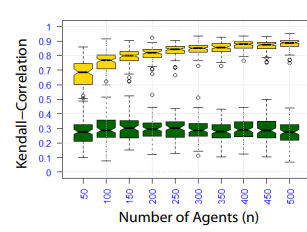

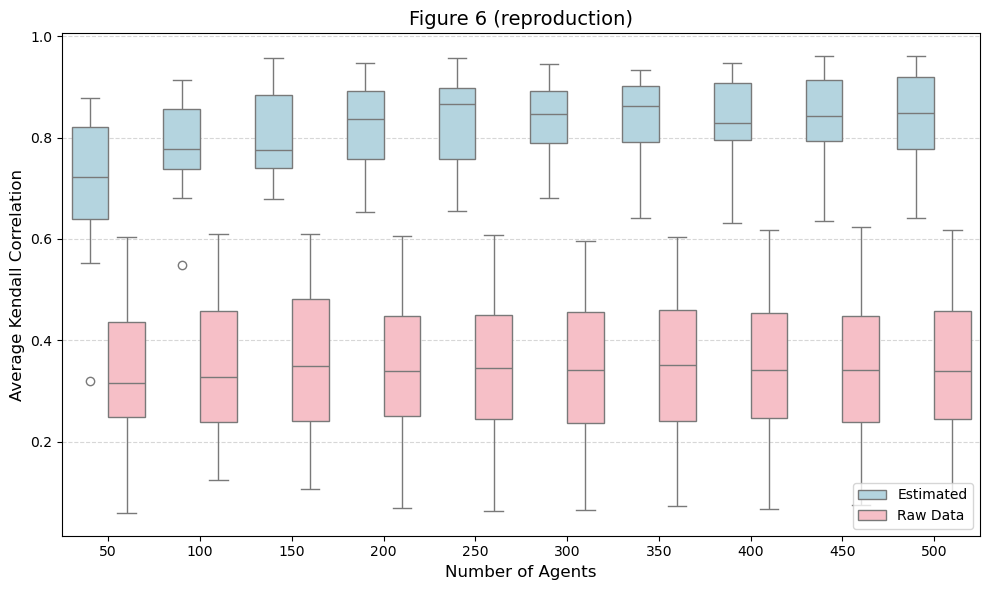

In [6]:
show_original("Figure6.png")

R = _resolve_run_dir(FIG6_RUN, "fig6-repro-*")
inferred_list: list[dict] = []
raw_list: list[dict] = []
for f in sorted((R / "outputs").glob("*.json")):
    data = json.loads(f.read_text(encoding="utf-8"))
    for pt in data.get("asymptotic", []):
        n_agents = pt["n_agents"]
        inferred_list.append({"n_agents": n_agents, "correlation": float(pt["mean_tau"]), "type": "Estimated"})
        raw_list.append(
            {
                "n_agents": n_agents,
                "correlation": float(pt.get("raw_mean_tau", 0.0)),
                "type": "Raw Data",
            }
        )
df6 = pd.DataFrame(inferred_list + raw_list)
if df6.empty:
    raise ValueError("No asymptotic points in Figure 6 outputs.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df6, x="n_agents", y="correlation", hue="type", palette={"Estimated": "lightblue", "Raw Data": "lightpink"})
plt.title("Figure 6 (reproduction)", fontsize=14)
plt.xlabel("Number of Agents", fontsize=12)
plt.ylabel("Average Kendall Correlation", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()
